## MERFISH mouse liver: Notebook to determine ROIs for overlapping cells in 3d spot-based transcriptomics data

This notebook contains a prototype implementation of an ovrl.py analysis script for vizgen's MERFISH liver showcase data set. It runs tha basic ovrlpy analysis pipeline and stores the result;

In [1]:
%matplotlib inline

#### Imports:

In [2]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import ovrlpy
import pandas as pd
import polars as pl
from matplotlib_scalebar.scalebar import ScaleBar

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys

sys.path.append("..")

from utils import CM, FONT, plot_doublet, plot_transcripts, save_kwargs

matplotlib.rc("font", **FONT)

In [4]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True, parents=True)

#### Parameter definition:

In [5]:
n_sample = 1
n_slice = 1

merfish_dir = Path(
    f"/dh-projects/ag-ishaque/raw_data/vizgen-merfish/vz-liver-showcase/Liver{n_sample}Slice{n_slice}"
)

coordinate_path = merfish_dir / "detected_transcripts.csv"

signature_file = (
    Path("/dh-projects/ag-ishaque/analysis/tiesmeys/data/ovrlpy/signatures")
    / "signatures_liver_atlas.csv"
)

In [6]:
signatures = pd.read_csv(signature_file, index_col=0).T

In [6]:
coordinate_df = ovrlpy.io.read_MERSCOPE(coordinate_path)

In [7]:
# subset coordinates
x_lims = [2000, 9000]
y_lims = [1000, 8000]

coordinate_df = coordinate_df.filter(
    pl.col("x") > x_lims[0],
    pl.col("x") < x_lims[1],
    pl.col("y") > y_lims[0],
    pl.col("y") < y_lims[1],
).with_columns(
    pl.col("x") - x_lims[0],
    pl.col("y") - y_lims[0],
)

In [8]:
print(
    f"Number of genes: {coordinate_df['gene'].n_unique():,}",
    f"Number of molecules: {coordinate_df.shape[0]:,}",
    sep="\n",
)

Number of genes: 347
Number of molecules: 276,188,705


In [9]:
liver = ovrlpy.Ovrlp(
    coordinate_df,
    n_components=15,
    min_distance=6,
    KDE_bandwidth=1.7,
    random_state=42,
    n_workers=16,
)
liver.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 117646 pseudocells
sampling expression:


100%|██████████| 81/81 [06:00<00:00,  4.45s/it]


Modeling 15 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 196/196 [07:56<00:00,  2.43s/it]


In [10]:
signal_integrity = liver.integrity_map
signal_strength = liver.signal_map

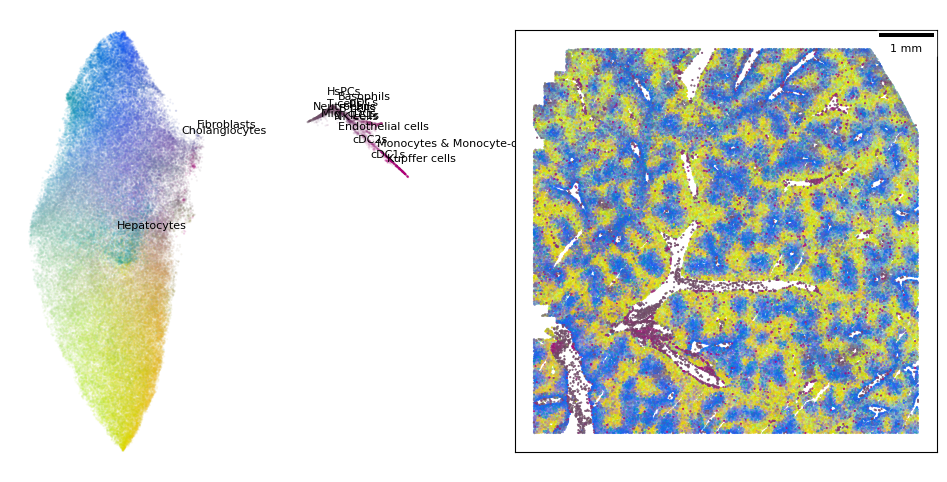

In [12]:
liver.fit_signatures(signatures)

fig = ovrlpy.plot_pseudocells(liver)
fig.axes[1].set(xticks=[], yticks=[])

fig.savefig(out_dir / "liver-fit.pdf", dpi=600)
fig.savefig(out_dir / "liver-fit.svg", dpi=600)

In [13]:
import pickle

with open("merscope_liver.pickle", "wb") as file:
    pickle.dump(liver, file)

In [7]:
import pickle

with open("merscope_liver.pickle", "rb") as file:
    liver = pickle.load(file)

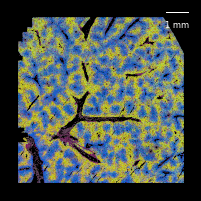

In [8]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(6 * CM, 6 * CM))
    _ = ovrlpy.plot_tissue(
        liver,
        ax=ax,
        scalebar={"dx": 1, "units": "um", "frameon": False, "color": "w"},
        **scatter_kwargs,
    )
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)
    fig.savefig(out_dir / "localmaxima.svg", **save_kwargs)

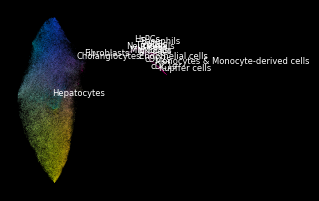

In [9]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(6 * CM, 6 * CM))
    _ = ovrlpy.plot_umap(liver, ax=ax, scatter_kwargs=scatter_kwargs)
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)

    for t in fig.axes[0].texts:
        t.set(color="white")

    fig.savefig(out_dir / "umap.svg", **save_kwargs)

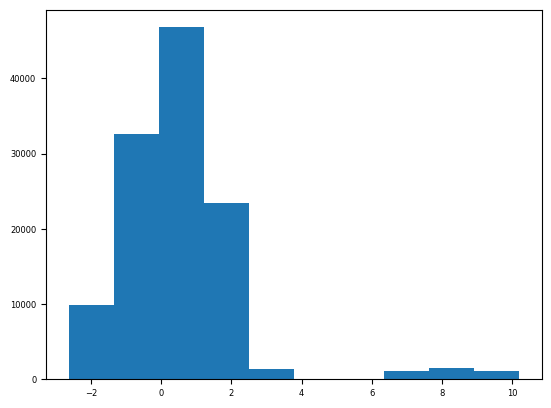

In [10]:
_ = plt.hist(liver.pseudocells.obsm["2D_UMAP"][:, 0])

In [11]:
umap_delimiter = 5  # values with embedding.x < umap_delimiter are stromal
stromal_mask = liver.pseudocells.obsm["2D_UMAP"][:, 0] > umap_delimiter

In [14]:
from copy import deepcopy

liver_stromal = deepcopy(liver)

liver_stromal.pca.set_params(n_components=12)

liver_stromal.fit_pseudocells(liver.pseudocells[stromal_mask, :].copy())
liver_stromal.fit_signatures(signatures)

Modeling 12 pseudo-celltype clusters;


In [15]:
rgb_array = liver.pseudocells.obsm["RGB"].copy()
rgb_array[:] = rgb_array.mean(1, keepdims=True)
rgb_array[stromal_mask] = liver_stromal.pseudocells.obsm["RGB"].copy()

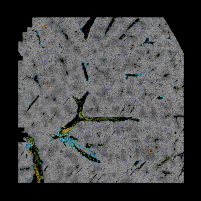

In [26]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=0.2, lw=0)

    fig, ax = plt.subplots(figsize=(6 * CM, 6 * CM))
    ax.scatter(
        liver.pseudocells.obsm["spatial"][:, 0],
        liver.pseudocells.obsm["spatial"][:, 1],
        c=rgb_array,
        rasterized=True,
        **scatter_kwargs,
    )
    ax.set(aspect="equal")
    ax.set_axis_off()
    fig.savefig(out_dir / "localmaxima_recolored.svg", **save_kwargs)

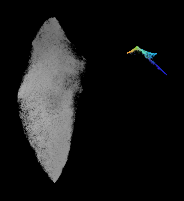

In [25]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=0.1, lw=0)

    fig, ax = plt.subplots(figsize=(6 * CM, 6 * CM))
    ax.scatter(
        liver.pseudocells.obsm["2D_UMAP"][:, 0],
        liver.pseudocells.obsm["2D_UMAP"][:, 1],
        c=rgb_array,
        rasterized=True,
        **scatter_kwargs,
    )
    ax.set(aspect="equal")
    ax.axis("off")

    fig.savefig(out_dir / "umap_recolored.svg", **save_kwargs)

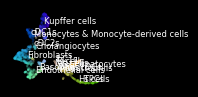

In [24]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=10, lw=0)

    fig, ax = plt.subplots(figsize=(3 * CM, 3 * CM))
    _ = ovrlpy.plot_umap(liver_stromal, ax=ax, scatter_kwargs=scatter_kwargs)
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)

    for t in fig.axes[0].texts:
        t.set(color="white")

    fig.savefig(out_dir / "umap_stromal_recolored.svg", **save_kwargs)

In [27]:
from copy import deepcopy

liver_stromal_old_color = deepcopy(liver_stromal)

In [29]:
liver_stromal_old_color.pseudocells.obsm["RGB"] = liver.pseudocells.obsm["RGB"][
    stromal_mask, :
]

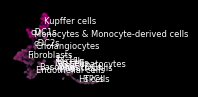

In [31]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=10, lw=0)

    fig, ax = plt.subplots(figsize=(3 * CM, 3 * CM))
    _ = ovrlpy.plot_umap(liver_stromal_old_color, ax=ax, scatter_kwargs=scatter_kwargs)
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)

    for t in fig.axes[0].texts:
        t.set(color="white")

    fig.savefig(out_dir / "umap_stromal.svg", **save_kwargs)

In [19]:
doublet_df = liver.detect_doublets(min_signal=3, integrity_sigma=2)

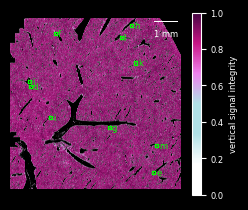

In [20]:
fig = ovrlpy.plot_signal_integrity(
    liver,
    histogram=False,
    scalebar={"dx": 1, "units": "um", "frameon": False, "color": "w"},
    figsize=(7 * CM, 6 * CM),
)

fig.axes[0].set(xticks=[], yticks=[])
fig.axes[0].axis("off")

alphabet = "abcdefghijklmnopqrstuvwxyz"

for i in range(10):
    x, y = doublet_df["x", "y"].row(i)

    fig.axes[0].text(x + 100, y, alphabet[i + 3], color="lime", fontsize=6, va="center")
    fig.axes[0].scatter(
        x, y, marker="s", s=5, edgecolors="lime", facecolors="None", lw=1
    )

fig.savefig("liver_integrity.svg", **save_kwargs)

In [ ]:
doublet_dir = out_dir / "doublet-case-visualizations"
doublet_dir.mkdir(exist_ok=True, parents=True)

with plt.style.context("dark_background"):
    for i in range(10):
        x, y = doublet_df["x", "y"].row(i)
        fig = plot_doublet(liver, x, y, signal_threshold=2, figsize=(9 * CM, 3 * CM))
        for j in range(4):
            fig.axes[j].collections[0].set_rasterized(True)
        fig.axes[0].add_artist(
            ScaleBar(
                1,
                units="um",
                length_fraction=0.2,
                loc="lower left",
                frameon=False,
                color="w",
            )
        )
        fig.savefig(doublet_dir / f"doublet_case_{i + 1}.svg", **save_kwargs)

In [22]:
def recolor_liver(ovrlp, transcripts, t):
    embedding, embedding_color = ovrlp.transform_transcripts(transcripts)
    stromal_mask = embedding[:, 0] > t
    embedding_color[:] = embedding_color.mean(axis=1)[:, None]

    return stromal_mask, embedding_color


def plot_doublet_recolor(
    ovrlp, ovrlp2, x, y, t, window_size=50, signal_threshold=2, figsize=(9 * CM, 3 * CM)
):
    signal_integrity = ovrlp.integrity_map[
        int(y) - window_size : int(y) + window_size,
        int(x) - window_size : int(x) + window_size,
    ]

    signal_strength = ovrlp.signal_map[
        int(y) - window_size : int(y) + window_size,
        int(x) - window_size : int(x) + window_size,
    ]

    roi_transcripts = ovrlp.subset_transcripts(x, y, window_size=window_size).sort("z")

    mask, embedding_color = recolor_liver(ovrlp, roi_transcripts, t)

    _, embedding_color2 = ovrlp2.transform_transcripts(roi_transcripts.filter(mask))
    embedding_color[mask] = embedding_color2
    roi_transcripts = roi_transcripts.with_columns(RGB=embedding_color)

    return plot_transcripts(
        roi_transcripts,
        signal_integrity,
        signal_strength,
        x,
        y,
        window_size,
        signal_threshold=signal_threshold,
        figsize=figsize,
    )

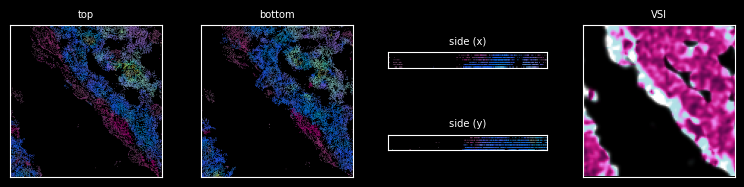

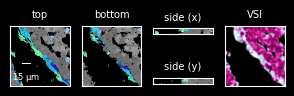

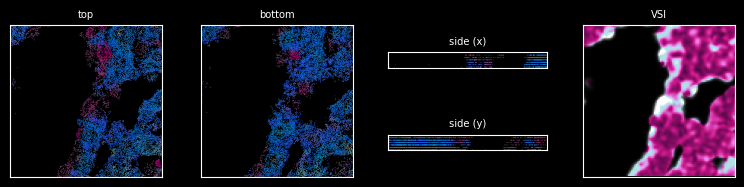

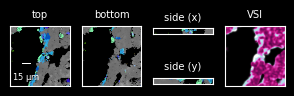

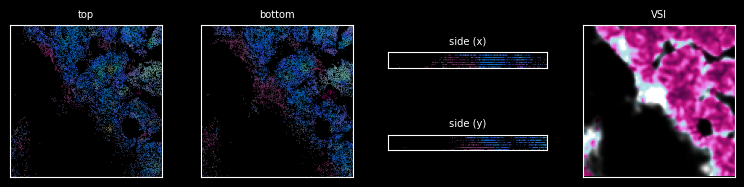

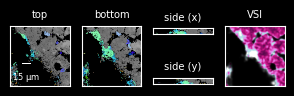

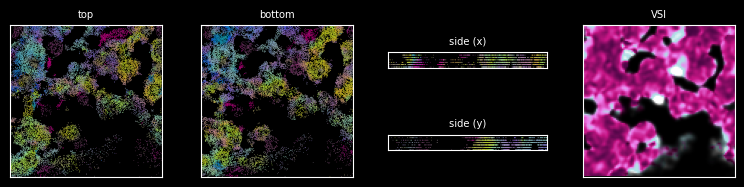

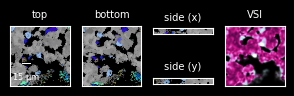

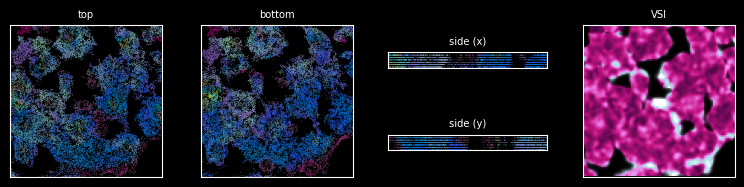

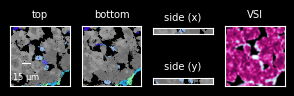

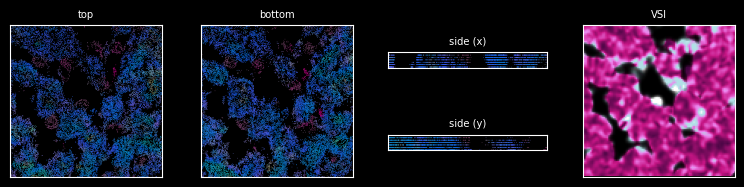

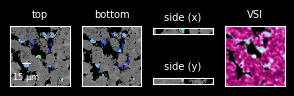

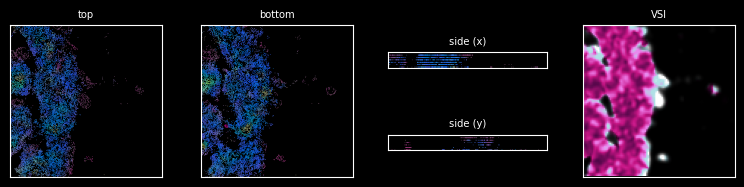

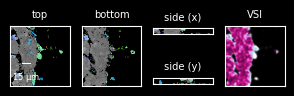

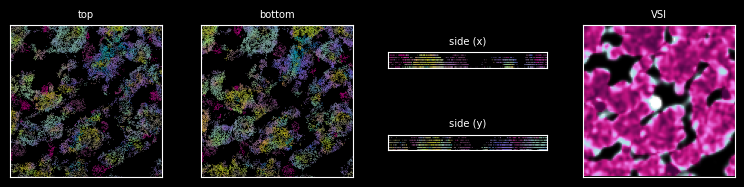

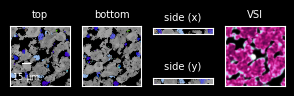

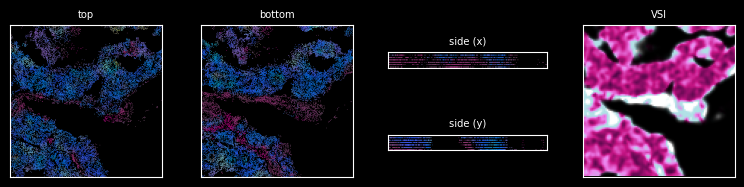

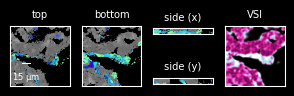

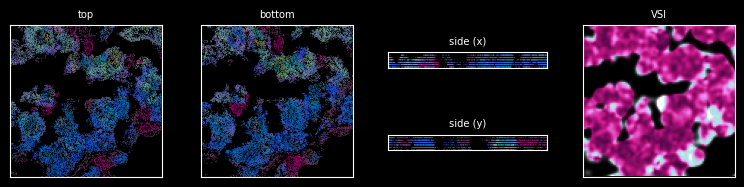

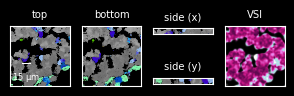

In [23]:
doublet_dir = out_dir / "doublet-case-visualizations_recolored"
doublet_dir.mkdir(exist_ok=True, parents=True)


with plt.style.context("dark_background"):
    for i in range(10):
        x, y = doublet_df["x", "y"].row(i)
        fig = plot_doublet(liver, x, y, signal_threshold=2)
        fig = plot_doublet_recolor(liver, liver_stromal, x, y, umap_delimiter)
        for j in range(4):
            fig.axes[j].collections[0].set_rasterized(True)
        fig.axes[0].add_artist(
            ScaleBar(
                1,
                units="um",
                length_fraction=0.2,
                loc="lower left",
                frameon=False,
                color="w",
            )
        )
        fig.savefig(doublet_dir / f"doublet_case_{i + 1}.svg", **save_kwargs)